# Market brief — email preview

Renders the same HTML email the scheduled GitHub Action (`Market brief` AM/Midday/PM) would send, using live data. Change `SLOT` between `"am"`, `"midday"`, `"pm"` to preview each variant — `pm` includes a WTD column.

Imports directly from `scripts/market_brief.py` so this notebook and the cron output cannot drift apart.

In [6]:
import sys
from pathlib import Path

# Make scripts/ importable
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "scripts"))

from IPython.display import HTML, display

from market_brief import build_email

SLOT = "pm"  # "am" | "midday" | "pm"

## Fetch + render

`build_email` does the yfinance + BoE + Bundesbank fetches, computes moves, generates the section charts, and returns `(subject, html)` — exactly what the cron job sends.

Subject: Market brief — PM — 2026-04-25
HTML size: 104,603 chars


TICKER,LAST,DAILY %,WTD %
^GSPC,"7,165.08",+0.80%,+0.55%
^NDX,"27,303.67",+1.95%,+2.37%
^STOXX50E,"5,883.48",-0.19%,-2.88%
^FTSE,"10,379.10",-0.74%,-2.70%
^N225,"59,716.18",+0.97%,+2.12%
^HSI,"25,978.07",+0.24%,-0.70%
TICKER,LAST,Δ BPS,WTD Δ
US 3M,3.59%,-0.2 bps,-0.7 bps
US 5Y,3.92%,-3.2 bps,+8.2 bps
US 10Y,4.31%,-1.3 bps,+6.4 bps

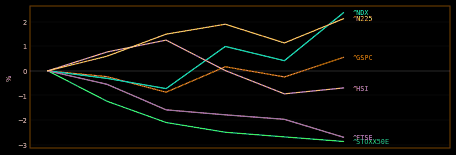
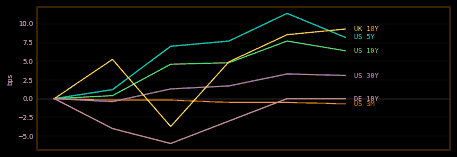
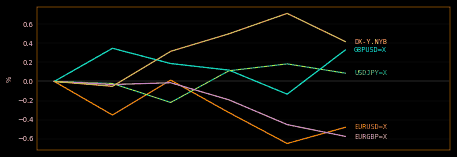
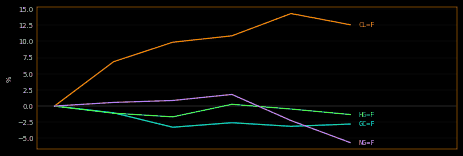
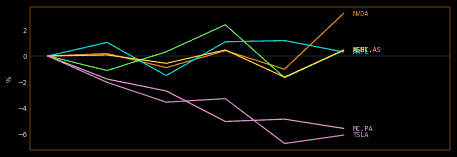
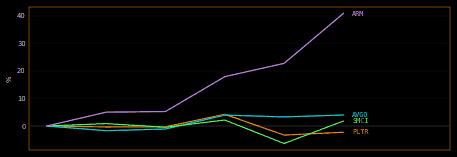

In [7]:
subject, html = build_email(SLOT)
print("Subject:", subject)
print(f"HTML size: {len(html):,} chars")
display(HTML(html))